In [129]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))



In [130]:
import src
from src.linear_regression_gd import LinearRegressionGradientDescent


In [131]:
model = LinearRegressionGradientDescent()

In [132]:
df = pd.read_csv('../data/height_weight.csv')
df.drop(columns=['Index'],axis=1,inplace=True)
df.rename(columns={"Height(Inches)":"height","Weight(Pounds)":"weight"},inplace=True)
df.head()

,height,weight
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


In [133]:
X = df['height'].to_numpy() # input feature 
y  = df['weight']  # output feature

Text(0.5, 1.0, 'Correlation between height and weight')

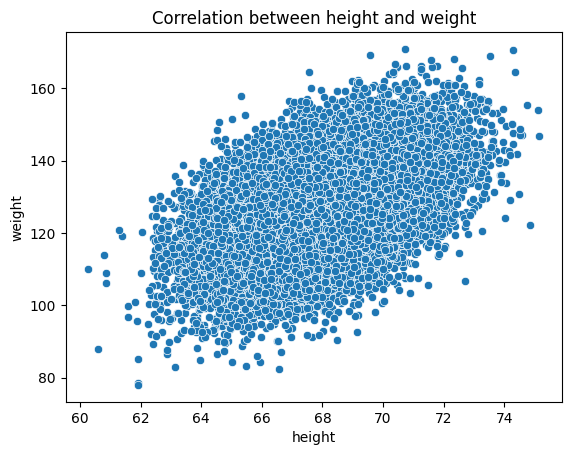

In [134]:
sns.scatterplot(x=df['height'],y=df['weight'])
plt.title('Correlation between height and weight')


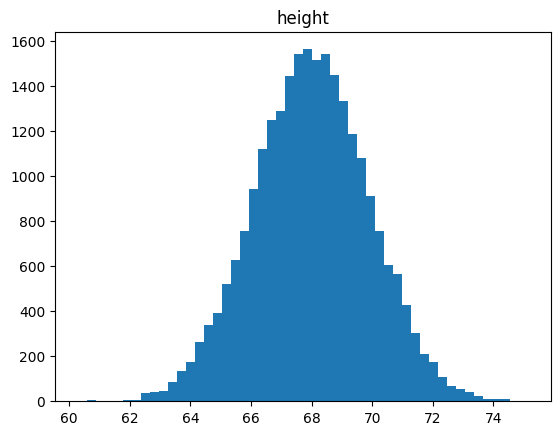

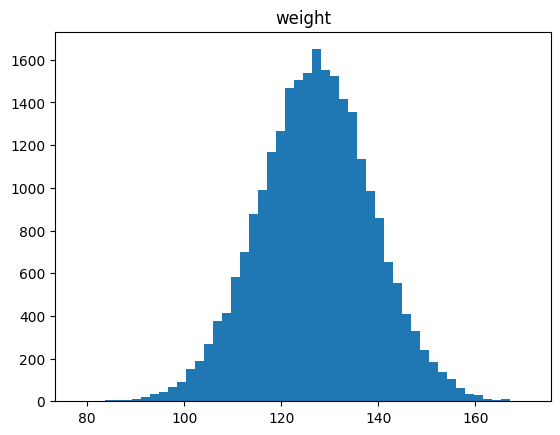

In [135]:
plt.hist(x=df['height'],bins=50)
plt.title("height")
plt.show()
plt.hist(x=df['weight'],bins=50)
plt.title('weight')
plt.show()

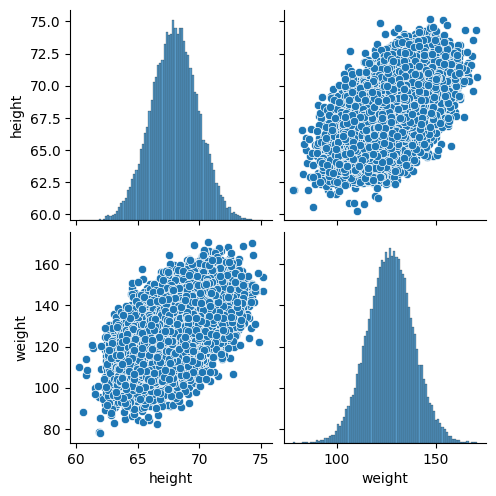

In [136]:
# pairplot 
sns.pairplot(data=df)


<Axes: >

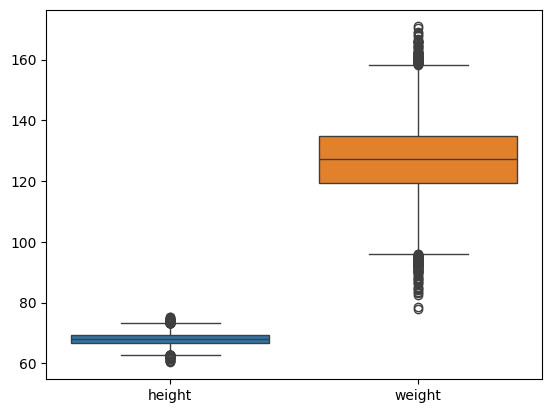

In [137]:
# boxplot
sns.boxplot(data=df)

In [138]:
df.corr()

,height,weight
height,1.000000,0.502859
weight,0.502859,1.000000


In [139]:
model.fit(X,y)

In [140]:
print(str(model))

Beta0: -0.0370, Beta1: 1.8705


In [141]:
y_pred = model.predict(X)
y_pred

array([123.01048715, 133.73199348, 129.773141  , ..., 120.98144596,
       126.27613314, 128.79836849], shape=(25000,))

In [142]:
model.summary(y,y_pred)

RMSE :  10.339889989904814
R2_SCORE :  0.21370548179481608
MAE :  8.238319015783157
MSE :  106.91332500333377


In [143]:
beta1 = model.beta1
beta0 = model.beta0
beta1,beta0

(np.float64(1.8704977971127499), np.float64(-0.03704928841893452))

<Axes: ylabel='weight'>

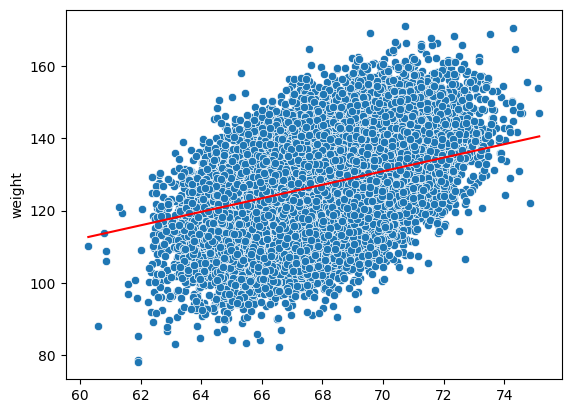

In [144]:
sns.scatterplot(x=X,y=y)
sns.lineplot(x=X,y=beta0 +beta1*X,color='red')

In [145]:
residual = y - y_pred
residual

0       -10.017987
1         2.755307
2        23.253759
3        14.773449
4        17.537200
           ...    
24995   -11.935369
24996    -0.507129
24997    -2.715946
24998     5.992067
24999    -3.924168
Name: weight, Length: 25000, dtype: float64

Text(0.5, 1.0, 'Residuals')

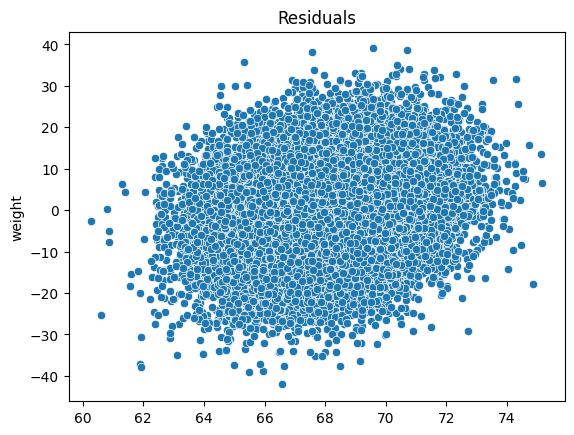

In [146]:
sns.scatterplot(x=X,y=residual)
plt.title('Residuals')

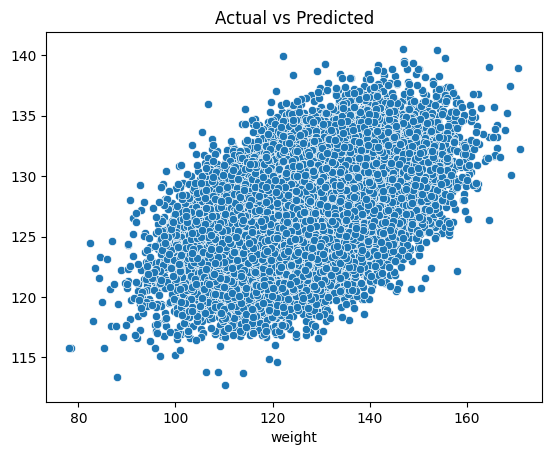

In [147]:
sns.scatterplot(x=y,y=y_pred)
plt.title('Actual vs Predicted')
plt.show()

In [148]:
beta0_history =np.array(model.beta0_history)
slope_history = np.array(model.slope_history)


Text(0, 0.5, 'slope of the curve')

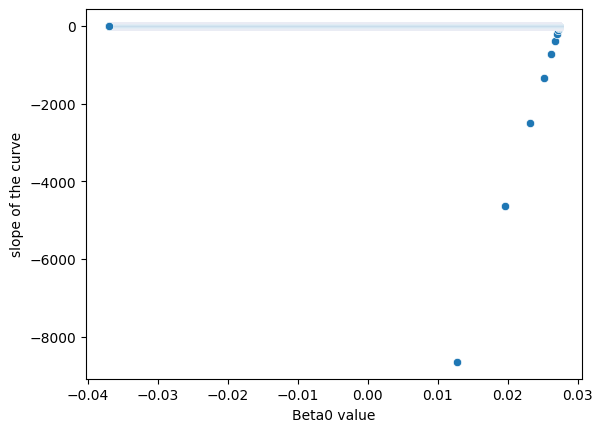

In [149]:
sns.scatterplot(x=beta0_history,y=slope_history)
plt.xlabel("Beta0 value")
plt.ylabel("slope of the curve")

Text(0, 0.5, 'Loss')

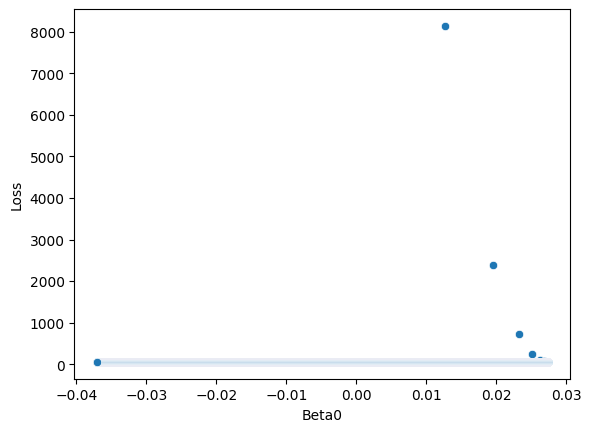

In [150]:
loss = np.array(model.loss_history)
sns.scatterplot(x=beta0_history,y=loss)
plt.xlabel("Beta0")
plt.ylabel("Loss")